## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_nuts3_gdf = gpd.read_file(f"{folder_path}/elladitsa_nomoi.shp",  encoding=dec)
greece_nuts2_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
greece_rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((385995.813 4480598.500, 385855..."
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((444114.046 4201703.450, 444095..."
2,33000000,33000000,Ν. ΙΩΑΝΝΙΝΩΝ,N. IOANNINON,161027,ΙΩΑΝΝΙΝΑ,459160.764413,4.999038e+09,"POLYGON ((234505.297 4469743.499, 234459.375 4..."
3,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((350911.406 4558247.998, 350936.187 4..."
4,05000000,05000000,Ν. ΕΥΡΥΤΑΝΙΑΣ,N. EVRYTANIAS,19518,ΚΑΡΠΕΝΗΣΙ,267851.316606,1.870664e+09,"POLYGON ((296728.718 4346288.000, 296808.656 4..."


In [6]:
greece_nuts2_gdf.head(5)

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [7]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')
print(f'greece_rivers CRS: {greece_rivers_gdf.crs}')

greece_nuts3 CRS: epsg:2100
greece_nuts2 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
greece_rivers CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [8]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_rivers_gdf = greece_rivers_gdf.to_crs(epsg=4326)

In [9]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')
print(f'greece_rivers CRS: {greece_rivers_gdf.crs}')

greece_nuts3 CRS: epsg:4326
greece_nuts2 CRS: epsg:4326
greece_rivers CRS: epsg:4326


In [10]:
greece_nuts3_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40..."
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((23.36549 37.96383, 23.36527 37..."
2,33000000,33000000,Ν. ΙΩΑΝΝΙΝΩΝ,N. IOANNINON,161027,ΙΩΑΝΝΙΝΑ,459160.764413,4.999038e+09,"POLYGON ((20.87623 40.33865, 20.87576 40.33726..."
3,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((22.22469 41.16447, 22.22498 41.16444..."
4,05000000,05000000,Ν. ΕΥΡΥΤΑΝΙΑΣ,N. EVRYTANIAS,19518,ΚΑΡΠΕΝΗΣΙ,267851.316606,1.870664e+09,"POLYGON ((21.64628 39.24473, 21.64720 39.24471..."


In [11]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 55


In [12]:
greece_nuts2_gdf.head(5)

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [13]:
print(f'Length of greece_nuts2_gdf: {len(greece_nuts2_gdf)}')

Length of greece_nuts2_gdf: 13


In [14]:
#choose the correct region

region = greece_nuts2_gdf.loc[greece_nuts2_gdf['PER'] == 'Π. ΘΕΣΣΑΛΙΑΣ'].copy()
region.head()

,PER,geometry
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [15]:
print(f'region CRS: {region.crs}')

region CRS: epsg:4326


In [16]:
nuts2_gdf = gpd.sjoin(greece_nuts3_gdf, region, how = 'inner', op='intersects')

In [17]:
nuts2_gdf.head()

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry,index_right,PER
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40...",4,Π. ΘΕΣΣΑΛΙΑΣ
2,33000000,33000000,Ν. ΙΩΑΝΝΙΝΩΝ,N. IOANNINON,161027,ΙΩΑΝΝΙΝΑ,459160.764413,4.999038e+09,"POLYGON ((20.87623 40.33865, 20.87576 40.33726...",4,Π. ΘΕΣΣΑΛΙΑΣ
4,05000000,05000000,Ν. ΕΥΡΥΤΑΝΙΑΣ,N. EVRYTANIAS,19518,ΚΑΡΠΕΝΗΣΙ,267851.316606,1.870664e+09,"POLYGON ((21.64628 39.24473, 21.64720 39.24471...",4,Π. ΘΕΣΣΑΛΙΑΣ
6,01000000,01000000,Ν. ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ,N. ETOLOAKARNANIAS,219092,ΜΕΣΟΛΟΓΓΙ,905135.516052,5.425151e+09,"MULTIPOLYGON (((21.48648 38.29815, 21.48629 38...",4,Π. ΘΕΣΣΑΛΙΑΣ
7,42000000,42000000,Ν. ΛΑΡΙΣΑΣ,N. LARISAS,282156,ΛΑΡΙΣΑ,479120.018907,5.385277e+09,"POLYGON ((22.18705 40.19547, 22.18798 40.19535...",4,Π. ΘΕΣΣΑΛΙΑΣ


<AxesSubplot:>

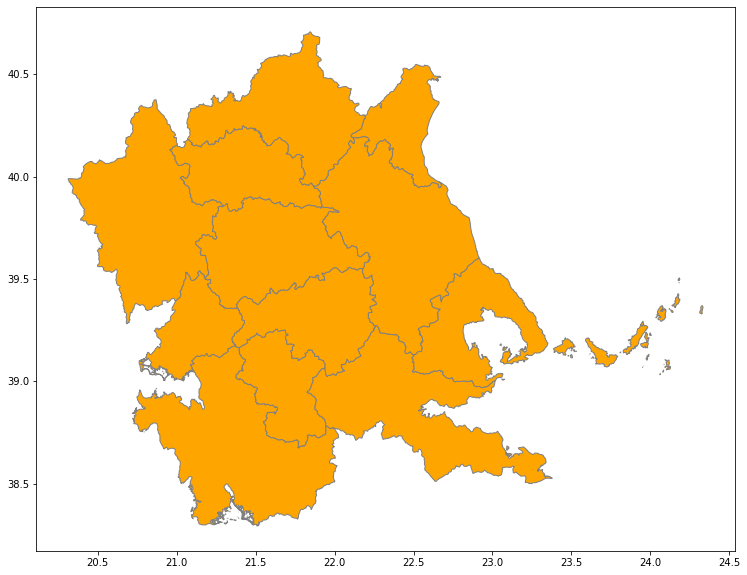

In [18]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [19]:
nuts2_gdf.NAME_GR.unique()

array(['Ν. ΠΙΕΡΙΑΣ', 'Ν. ΙΩΑΝΝΙΝΩΝ', 'Ν. ΕΥΡΥΤΑΝΙΑΣ',
       'Ν. ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ', 'Ν. ΛΑΡΙΣΑΣ', 'Ν. ΚΟΖΑΝΗΣ', 'Ν. ΦΘΙΩΤΙΔΑΣ',
       'Ν. ΓΡΕΒΕΝΩΝ', 'Ν. ΜΑΓΝΗΣΙΑΣ', 'Ν. ΚΑΡΔΙΤΣΑΣ', 'Ν. ΑΡΤΑΣ',
       'Ν. ΤΡΙΚΑΛΩΝ'], dtype=object)

In [27]:
#check QGIS for wrong lau1 units

In [20]:
wrong_list = ['Ν. ΠΙΕΡΙΑΣ', 'Ν. ΙΩΑΝΝΙΝΩΝ', 'Ν. ΕΥΡΥΤΑΝΙΑΣ', 'Ν. ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ', 'Ν. ΚΟΖΑΝΗΣ', 'Ν. ΦΘΙΩΤΙΔΑΣ',
       'Ν. ΓΡΕΒΕΝΩΝ', 'Ν. ΑΡΤΑΣ']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME_GR'].isin(wrong_list)].copy()

In [21]:
nuts2_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry,index_right,PER
7,42000000,42000000,Ν. ΛΑΡΙΣΑΣ,N. LARISAS,282156,ΛΑΡΙΣΑ,479120.018907,5.385277e+09,"POLYGON ((22.18705 40.19547, 22.18798 40.19535...",4,Π. ΘΕΣΣΑΛΙΑΣ
40,43000000,43000000,Ν. ΜΑΓΝΗΣΙΑΣ,N. MAGNISIAS,205005,ΒΟΛΟΣ,842435.709348,2.636536e+09,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39...",4,Π. ΘΕΣΣΑΛΙΑΣ
44,41000000,41000000,Ν. ΚΑΡΔΙΤΣΑΣ,N. KARDITSAS,120265,ΚΑΡΔΙΤΣΑ,337575.611224,2.638041e+09,"POLYGON ((22.03888 39.53659, 22.04287 39.53411...",4,Π. ΘΕΣΣΑΛΙΑΣ
53,44000000,44000000,Ν. ΤΡΙΚΑΛΩΝ,N. TRIKALON,132689,ΤΡΙΚΑΛΑ,368506.501009,3.385824e+09,"POLYGON ((21.46677 39.90052, 21.46906 39.90015...",4,Π. ΘΕΣΣΑΛΙΑΣ


In [22]:
nuts2_gdf.drop(columns=['PARENT', 'ESYE_ID', 'NAME_ENG', 'POP', 'EDRA', 'SHAPE_LENG', 'SHAPE_AREA'], inplace = True)
nuts2_gdf.rename(columns={"NAME_GR": "nuts3"}, inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'nuts3')

In [23]:
nuts2_gdf.head(5)

,nuts3,geometry,index_right,PER
0,λαρισας,"POLYGON ((22.18705 40.19547, 22.18798 40.19535...",4,Π. ΘΕΣΣΑΛΙΑΣ
1,μαγνησιας,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39...",4,Π. ΘΕΣΣΑΛΙΑΣ
2,καρδιτσας,"POLYGON ((22.03888 39.53659, 22.04287 39.53411...",4,Π. ΘΕΣΣΑΛΙΑΣ
3,τρικαλων,"POLYGON ((21.46677 39.90052, 21.46906 39.90015...",4,Π. ΘΕΣΣΑΛΙΑΣ


<AxesSubplot:>

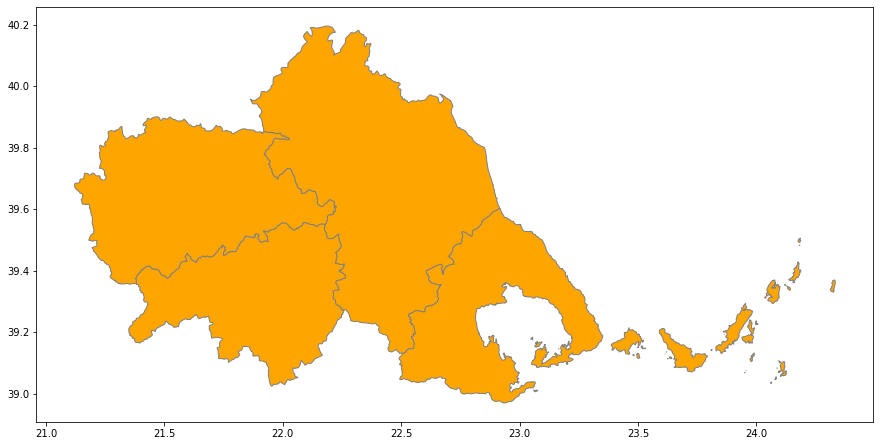

In [24]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [25]:
nuts2_rivers_gdf = gpd.sjoin(greece_rivers_gdf, region, how = 'inner', op='intersects')

In [26]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry,index_right,PER
2,3,GR0004000400260520N,ÔÁÕÑÙÐÏÓ Ð.,TAVROPOS R.,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,42710.979405,"LINESTRING (21.76727 39.18674, 21.76728 39.186...",4,Π. ΘΕΣΣΑΛΙΑΣ
4,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495...",4,Π. ΘΕΣΣΑΛΙΑΣ
26,31,GR0008000400220550N,ÊÁÑÁÌÐÁËÇÓ Ð.,KARABALIS R.,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (21.93452 39.34592, 21.93566 39.346...",4,Π. ΘΕΣΣΑΛΙΑΣ
29,34,GR0008000400220580N,ÐÇÍÅÉÏÓ Ð.,PINIOS R.,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (22.02974 39.55998, 22.03116 39.561...",4,Π. ΘΕΣΣΑΛΙΑΣ
30,35,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,38733.609281,"LINESTRING (22.52914 39.30856, 22.52884 39.308...",4,Π. ΘΕΣΣΑΛΙΑΣ


<AxesSubplot:>

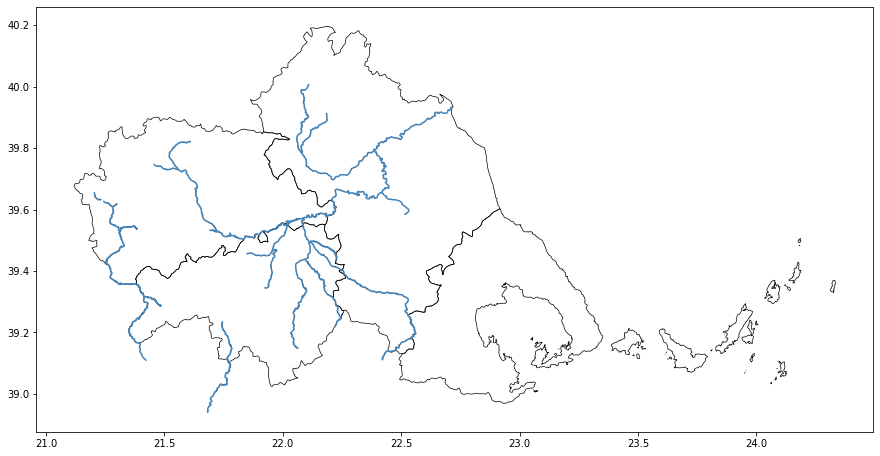

In [27]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [28]:
nuts3_units = nuts2_gdf['nuts3'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in Thessaly (from shapefile): 4


In [29]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [102]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='nuts3', dimension=4)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [103]:
df_grid.rename(columns={"NAME": "nuts3"}, inplace = True)

<AxesSubplot:>

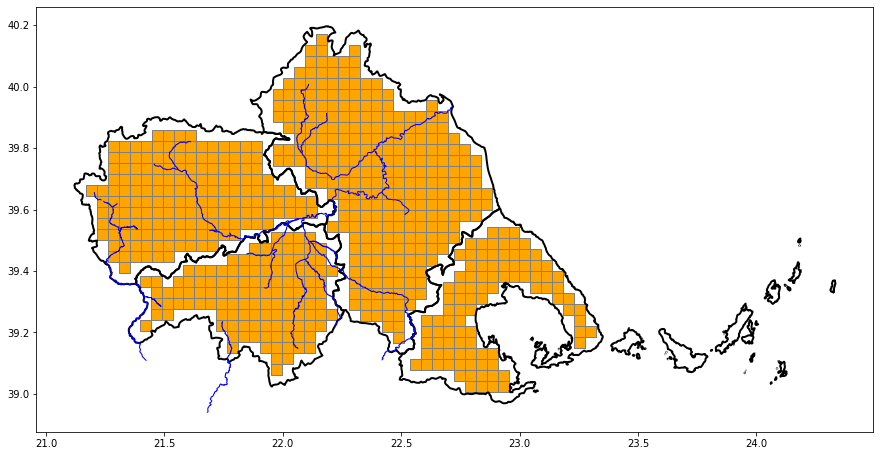

In [104]:
ax = nuts2_rivers_gdf.plot(figsize=(15, 15), cmap='jet', color='blue', lw=1)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [105]:
grid_nuts3 = df_grid['nuts3'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 4


In [106]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['nuts3'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['nuts3'] = lost_lau1['nuts3']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [107]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [108]:
nuts2_grid

,geometry,nuts3,x,y
0,"POLYGON ((22.00289 39.74133, 22.00289 39.77726...",λαρισας,21.97973,39.75929
1,"POLYGON ((22.00289 39.77726, 22.00289 39.81319...",λαρισας,21.97973,39.79523
2,"POLYGON ((22.00289 39.88506, 22.00289 39.92099...",λαρισας,21.97973,39.90303
3,"POLYGON ((22.00289 39.92099, 22.00289 39.95693...",λαρισας,21.97973,39.93896
4,"POLYGON ((22.00289 39.95693, 22.00289 39.99286...",λαρισας,21.97973,39.97489
...,...,...,...,...
657,"POLYGON ((22.04987 39.64352, 22.04987 39.67945...",τρικαλων,22.02663,39.66148
658,"POLYGON ((22.09634 39.57165, 22.09634 39.60758...",τρικαλων,22.07310,39.58962
659,"POLYGON ((22.09634 39.60758, 22.09634 39.64352...",τρικαλων,22.07310,39.62555
660,"POLYGON ((22.14281 39.57165, 22.14281 39.60758...",τρικαλων,22.11958,39.58962


In [109]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [110]:
nuts2_grid['nuts2'] = NUTS2_EL

In [111]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [112]:
nuts2_grid

,shape,nuts3,x,y,nuts2
0,"POLYGON ((22.00289 39.74133, 22.00289 39.77726...",λαρισας,21.97973,39.75929,θεσσαλιας
1,"POLYGON ((22.00289 39.77726, 22.00289 39.81319...",λαρισας,21.97973,39.79523,θεσσαλιας
2,"POLYGON ((22.00289 39.88506, 22.00289 39.92099...",λαρισας,21.97973,39.90303,θεσσαλιας
3,"POLYGON ((22.00289 39.92099, 22.00289 39.95693...",λαρισας,21.97973,39.93896,θεσσαλιας
4,"POLYGON ((22.00289 39.95693, 22.00289 39.99286...",λαρισας,21.97973,39.97489,θεσσαλιας
...,...,...,...,...,...
657,"POLYGON ((22.04987 39.64352, 22.04987 39.67945...",τρικαλων,22.02663,39.66148,θεσσαλιας
658,"POLYGON ((22.09634 39.57165, 22.09634 39.60758...",τρικαλων,22.07310,39.58962,θεσσαλιας
659,"POLYGON ((22.09634 39.60758, 22.09634 39.64352...",τρικαλων,22.07310,39.62555,θεσσαλιας
660,"POLYGON ((22.14281 39.57165, 22.14281 39.60758...",τρικαλων,22.11958,39.58962,θεσσαλιας


In [113]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [114]:
nuts2_grid_points

,shape,nuts3,x,y,nuts2,geometry
0,"POLYGON ((22.00289 39.74133, 22.00289 39.77726...",λαρισας,21.97973,39.75929,θεσσαλιας,POINT (21.97973 39.75929)
1,"POLYGON ((22.00289 39.77726, 22.00289 39.81319...",λαρισας,21.97973,39.79523,θεσσαλιας,POINT (21.97973 39.79523)
2,"POLYGON ((22.00289 39.88506, 22.00289 39.92099...",λαρισας,21.97973,39.90303,θεσσαλιας,POINT (21.97973 39.90303)
3,"POLYGON ((22.00289 39.92099, 22.00289 39.95693...",λαρισας,21.97973,39.93896,θεσσαλιας,POINT (21.97973 39.93896)
4,"POLYGON ((22.00289 39.95693, 22.00289 39.99286...",λαρισας,21.97973,39.97489,θεσσαλιας,POINT (21.97973 39.97489)
...,...,...,...,...,...,...
657,"POLYGON ((22.04987 39.64352, 22.04987 39.67945...",τρικαλων,22.02663,39.66148,θεσσαλιας,POINT (22.02663 39.66148)
658,"POLYGON ((22.09634 39.57165, 22.09634 39.60758...",τρικαλων,22.07310,39.58962,θεσσαλιας,POINT (22.07310 39.58962)
659,"POLYGON ((22.09634 39.60758, 22.09634 39.64352...",τρικαλων,22.07310,39.62555,θεσσαλιας,POINT (22.07310 39.62555)
660,"POLYGON ((22.14281 39.57165, 22.14281 39.60758...",τρικαλων,22.11958,39.58962,θεσσαλιας,POINT (22.11958 39.58962)


<AxesSubplot:>

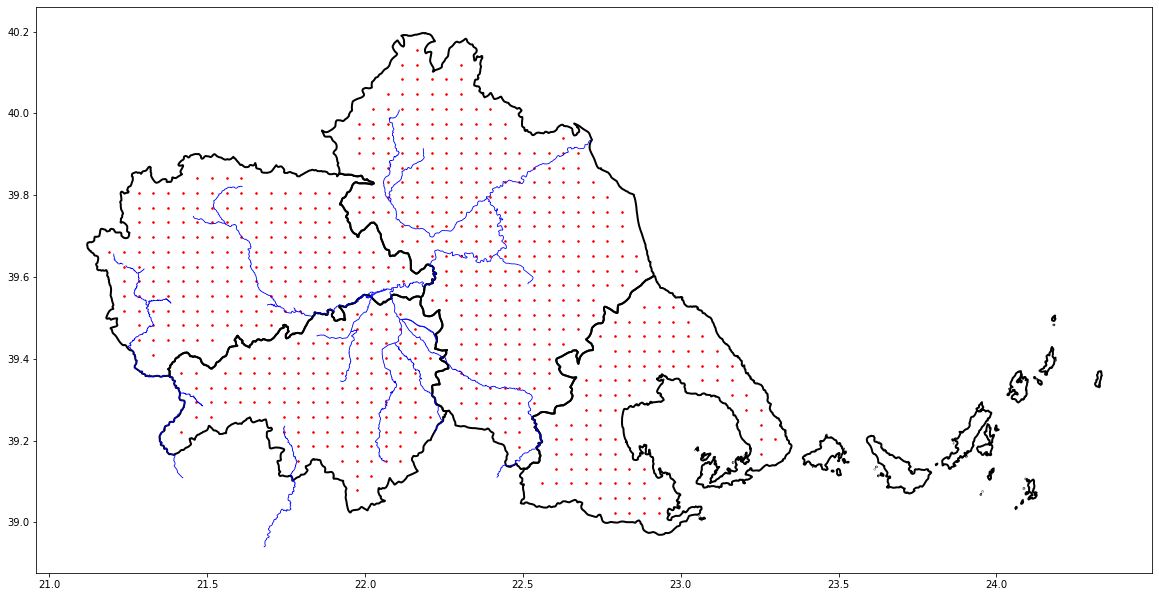

In [115]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=0.8)

In [116]:
final_grid = nuts2_grid[['nuts2', 'nuts3', 'x', 'y']].sort_values(by=['nuts3'])
final_grid.reset_index(drop = True, inplace= True)

In [117]:
final_grid

,nuts2,nuts3,x,y
0,θεσσαλιας,καρδιτσας,21.74256,39.29376
1,θεσσαλιας,καρδιτσας,22.02008,39.50936
2,θεσσαλιας,καρδιτσας,22.02008,39.47343
3,θεσσαλιας,καρδιτσας,22.02008,39.43750
4,θεσσαλιας,καρδιτσας,22.02008,39.40156
...,...,...,...,...
657,θεσσαλιας,τρικαλων,21.46896,39.62555
658,θεσσαλιας,τρικαλων,21.46896,39.66148
659,θεσσαλιας,τρικαλων,21.46896,39.69742
660,θεσσαλιας,τρικαλων,21.46896,39.76928


In [118]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)